<a href="https://colab.research.google.com/github/farhanwew/Information-retrieval/blob/main/CiSI_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Team 4 Information Retrieval Assignment 2
CISI Dataset — Retrieval & Reranking Comparison

| Name                              | Student ID  |
|:---------------------------------:|:-----------:|
| Faiz Muhammad Kautsar             | 5054231013  |
| Muhammad Rasyad Lubis             | 5054231010  |
| Muhammad Farhan Arya Wicaksono    | 5054231011  |
| Efan Ramdhani                     | 5054231017  |

This script adapts the agentic retrieval pipeline from Assignment 1 to work
with the CISI dataset. we use the
CISI corpus (1,460 documents, 112 queries, ground-truth relevance judgments).

Pipeline:
  1. Parse CISI.ALL, CISI.QRY, CISI.REL
  2. Initial retrieval via TF-IDF and BM25 (top-20 candidates)
  3. Rerank candidates with 6 methods:
     - SPLADE
     - BGE Dense
     - BGE Sparse (Lexical)
     - BGE ColBERT
     - BGE Hybrid (Dense + Sparse + ColBERT averaged)
     - BGE Reranker (Cross-Encoder)
  4. Evaluate with Precision@k, Recall@k, F1@k, MAP, MRR, nDCG@k
  5. Compare results across all method combinations

In [1]:
!pip install "transformers<5" FlagEmbedding rank_bm25

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 154.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 92.3 MB/s eta 0:00:00
  Created wheel for FlagEmbedding: filename=FlagEmbedding-1.3.5-py3-none-any.whl size=233746 sha256=1af6b3abd62a9ca77e6acb7244ea0a9cc282bd84f815e55e07dd5e97d0f3defe
  Stored in directory: /root/.cache/pip/wheels/b2/1f/f6/78f862bb80cb959cc

In [2]:
import os
import re
import numpy as np
import torch
from typing import List, Dict, Set, Tuple
from collections import defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi

from transformers import AutoModelForMaskedLM, AutoTokenizer
from FlagEmbedding import BGEM3FlagModel, FlagReranker

import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

##  Parse CISI Dataset

- **CISI.ALL**: 1,460 documents with `.I` (ID), `.T` (title), `.A` (author), `.W` (abstract), `.X` (cross-refs)
- **CISI.QRY**: 112 queries with `.I` (ID) and `.W` (query text)
- **CISI.REL**: Ground truth mapping query_id -> set of relevant doc_ids

In [3]:
! kaggle datasets download dmaso01dsta/cisi-a-dataset-for-information-retrieval

Dataset URL: https://www.kaggle.com/datasets/dmaso01dsta/cisi-a-dataset-for-information-retrieval
License(s): other
100% 759k/759k [00:00<00:00, 870kB/s]



In [4]:
!unzip cisi-a-dataset-for-information-retrieval.zip

Archive:  cisi-a-dataset-for-information-retrieval.zip
  inflating: CISI.ALL                
  inflating: CISI.QRY                
  inflating: CISI.REL                


In [5]:
DATA_DIR = os.path.join(".")

def parse_cisi_all(filepath: str) -> Dict[int, Dict]:
    """Parse CISI.ALL into a dict of {doc_id: {title, author, abstract}}."""
    documents = {}
    current_id = None
    current_field = None
    current_text = []

    def flush():
        nonlocal current_id, current_field, current_text
        if current_id is not None and current_field is not None:
            text = " ".join(current_text).strip()
            if current_id not in documents:
                documents[current_id] = {"id": current_id, "title": "", "author": "", "abstract": ""}
            if current_field == "T":
                documents[current_id]["title"] = text
            elif current_field == "A":
                documents[current_id]["author"] = text
            elif current_field == "W":
                documents[current_id]["abstract"] = text
        current_text = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(".I "):
                flush()
                current_id = int(line.split()[1])
                current_field = None
                if current_id not in documents:
                    documents[current_id] = {"id": current_id, "title": "", "author": "", "abstract": ""}
            elif line.startswith(".T"):
                flush()
                current_field = "T"
            elif line.startswith(".A"):
                flush()
                current_field = "A"
            elif line.startswith(".W"):
                flush()
                current_field = "W"
            elif line.startswith(".X"):
                flush()
                current_field = "X"  # we skip cross-refs
            else:
                if current_field in ("T", "A", "W"):
                    current_text.append(line.strip())
        flush()

    return documents


def parse_cisi_qry(filepath: str) -> Dict[int, str]:
    """Parse CISI.QRY into a dict of {query_id: query_text}."""
    queries = {}
    current_id = None
    current_field = None
    current_text = []

    def flush():
        nonlocal current_id, current_field, current_text
        if current_id is not None and current_field == "W":
            queries[current_id] = " ".join(current_text).strip()
        current_text = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(".I "):
                flush()
                current_id = int(line.split()[1])
                current_field = None
            elif line.startswith(".W"):
                flush()
                current_field = "W"
            elif line.startswith("."):
                flush()
                current_field = None
            else:
                if current_field == "W":
                    current_text.append(line.strip())
        flush()

    return queries


def parse_cisi_rel(filepath: str) -> Dict[int, Set[int]]:
    """Parse CISI.REL into a dict of {query_id: set of relevant doc_ids}."""
    relevance = defaultdict(set)
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                qid = int(parts[0])
                did = int(parts[1])
                relevance[qid].add(did)
    return dict(relevance)

In [6]:
# Parse everything
documents = parse_cisi_all(os.path.join(DATA_DIR, "CISI.ALL"))
queries = parse_cisi_qry(os.path.join(DATA_DIR, "CISI.QRY"))
relevance = parse_cisi_rel(os.path.join(DATA_DIR, "CISI.REL"))

# Build ordered lists for indexing
doc_ids = sorted(documents.keys())
doc_abstracts = [documents[did]["abstract"] for did in doc_ids]
doc_id_to_idx = {did: idx for idx, did in enumerate(doc_ids)}

print(f"Parsed {len(documents)} documents, {len(queries)} queries, "
      f"{sum(len(v) for v in relevance.values())} relevance judgments.")
print(f"Sample document (ID=1): {documents[1]['title'][:80]}...")
print(f"Sample query (ID=1): {queries[1][:80]}...")
print(f"Query 1 has {len(relevance.get(1, set()))} relevant documents.")

Parsed 1460 documents, 112 queries, 3114 relevance judgments.
Sample document (ID=1): 18 Editions of the Dewey Decimal Classifications...
Sample query (ID=1): What problems and concerns are there in making up descriptive titles? What diffi...
Query 1 has 46 relevant documents.


##  Initial Retrieval: TF-IDF


Build a TF-IDF matrix over all 1,460 document abstracts.

For each query, compute cosine similarity and return the top-20 candidates.

In [7]:
TOP_K = 20

# Build TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=10000)
tfidf_matrix = tfidf_vectorizer.fit_transform(doc_abstracts)

def retrieve_tfidf(query: str, top_k: int = TOP_K) -> List[Dict]:
    """Retrieve top-k documents using TF-IDF cosine similarity."""
    query_vec = tfidf_vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        did = doc_ids[idx]
        results.append({
            "id": did,
            "title": documents[did]["title"],
            "abstract": documents[did]["abstract"],
            "score": float(similarities[idx]),
        })
    return results


In [8]:
sample_results = retrieve_tfidf(queries[1])
print(queries[1])
print()

print(f"TF-IDF top-{TOP_K} for query 1:")
for i, r in enumerate(sample_results[:5]):
    print(f"  {i+1}. [Doc {r['id']}] score={r['score']:.4f} — {r['title'][:60]}")

What problems and concerns are there in making up descriptive titles? What difficulties are involved in automatically retrieving articles from approximate titles? What is the usual relevance of the content of articles to their titles?

TF-IDF top-20 for query 1:
  1. [Doc 722] score=0.3278 — Information Transfer Limitations of Titles of Chemical Docum
  2. [Doc 589] score=0.2381 — Are Titles of Chemical Papers Becoming More Informative?
  3. [Doc 429] score=0.2256 — The Information Content of Titles in Engineering Literature
  4. [Doc 1299] score=0.2134 — Current Physics Information
  5. [Doc 813] score=0.2128 — Comparative Efficiency of Searching Titles, Abstracts, and T


##  Initial Retrieval: BM25

 Build a BM25 index over tokenized document abstracts.

 For each query, return the top-20 candidates.

In [9]:
tokenized_abstracts = [abstract.lower().split() for abstract in doc_abstracts]
bm25_index = BM25Okapi(tokenized_abstracts)

def retrieve_bm25(query: str, top_k: int = TOP_K) -> List[Dict]:
    """Retrieve top-k documents using BM25."""
    tokenized_query = query.lower().split()
    scores = bm25_index.get_scores(tokenized_query)
    top_indices = scores.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        did = doc_ids[idx]
        results.append({
            "id": did,
            "title": documents[did]["title"],
            "abstract": documents[did]["abstract"],
            "score": float(scores[idx]),
        })
    return results

In [10]:
# Quick test
sample_results_bm25 = retrieve_bm25(queries[1])
print(queries[1])
print()
print(f"BM25 top-{TOP_K} for query 1:")
for i, r in enumerate(sample_results_bm25[:5]):
    print(f"  {i+1}. [Doc {r['id']}] score={r['score']:.4f} — {r['title'][:60]}")


What problems and concerns are there in making up descriptive titles? What difficulties are involved in automatically retrieving articles from approximate titles? What is the usual relevance of the content of articles to their titles?

BM25 top-20 for query 1:
  1. [Doc 17] score=49.2411 — Adventures in Librarianship
  2. [Doc 934] score=45.3769 — Library Education and the Public Library
  3. [Doc 1019] score=44.8502 — Determining the Optimal Number of Volumes for a Library's Co
  4. [Doc 1358] score=44.2318 — System Design, Evaluation, and Costing
  5. [Doc 1030] score=43.9397 — Little Science, Big Science


## Load Ranking Models


- **SPLADE**: `naver/splade-cocondenser-ensembledistil` — learned sparse representations
- **BGE-M3**: `BAAI/bge-m3` — dense, sparse (lexical), and ColBERT embeddings
- **BGE Reranker**: `BAAI/bge-reranker-v2-m3` — cross-encoder reranker

In [11]:
print("Loading models... this may take a while.")

# 1. SPLADE
splade_model_id = "naver/splade-cocondenser-ensembledistil"
splade_tokenizer = AutoTokenizer.from_pretrained(splade_model_id)
splade_model = AutoModelForMaskedLM.from_pretrained(splade_model_id)
splade_model.eval()
print("  SPLADE loaded.")

# 2. BGE-M3 (dense + sparse/lexical + colbert)
bge_m3 = BGEM3FlagModel("BAAI/bge-m3", use_fp16=True)
print("  BGE-M3 loaded.")

# 3. BGE Reranker (Cross-Encoder)
reranker = FlagReranker("BAAI/bge-reranker-v2-m3", use_fp16=True)
print("  BGE Reranker loaded.")

print("All models loaded successfully.")

Loading models... this may take a while.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

  BGE Reranker loaded.
All models loaded successfully.


## rank docs

 Rerank a list of candidate documents using one of 6 methods.


In [12]:
def get_splade_vecs(texts: List[str]):
    """Compute SPLADE sparse vectors for a list of texts."""
    with torch.no_grad():
        tokens = splade_tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
        output = splade_model(**tokens)
        vecs = torch.max(
            torch.log(1 + torch.relu(output.logits)) * tokens.attention_mask.unsqueeze(-1),
            dim=1,
        )[0]
    return vecs


def rank_docs(query: str, docs: List[Dict], method: str) -> List[Dict]:
    """Rerank documents using the specified method.

    Methods: splade, bge_dense, bge_sparse, bge_colbert, bge_hybrid, bge_reranker
    """
    if not docs:
        return []

    passages = [d["abstract"] for d in docs]

    if method == "splade":
        q_vec = get_splade_vecs([query])
        d_vecs = get_splade_vecs(passages)
        scores = torch.matmul(q_vec, d_vecs.T).squeeze(0).numpy()
        if scores.ndim == 0:
            scores = [scores.item()]
        else:
            scores = scores.tolist()

    elif method == "bge_reranker":
        pairs = [[query, p] for p in passages]
        scores = reranker.compute_score(pairs)
        if isinstance(scores, (float, int)):
            scores = [scores]

    else:
        # BGE-M3 variants
        q_out = bge_m3.encode([query], return_dense=True, return_sparse=True, return_colbert_vecs=True)
        d_out = bge_m3.encode(passages, return_dense=True, return_sparse=True, return_colbert_vecs=True)

        if method == "bge_dense":
            scores = (q_out["dense_vecs"] @ d_out["dense_vecs"].T)[0].tolist()

        elif method == "bge_sparse":
            scores = [
                bge_m3.compute_lexical_matching_score(q_out["lexical_weights"][0], d_out["lexical_weights"][i])
                for i in range(len(passages))
            ]

        elif method == "bge_colbert":
            scores = [
                bge_m3.colbert_score(q_out["colbert_vecs"][0], d_out["colbert_vecs"][i]).item()
                for i in range(len(passages))
            ]

        elif method == "bge_hybrid":
            scores = []
            for i in range(len(passages)):
                s_dense = (q_out["dense_vecs"] @ d_out["dense_vecs"].T)[0][i]
                s_lex = bge_m3.compute_lexical_matching_score(q_out["lexical_weights"][0], d_out["lexical_weights"][i])
                s_colbert = bge_m3.colbert_score(q_out["colbert_vecs"][0], d_out["colbert_vecs"][i]).item()
                scores.append((float(s_dense) + float(s_lex) + float(s_colbert)) / 3.0)

        else:
            raise ValueError(f"Unknown method: {method}")

    # Attach scores and sort descending
    ranked = []
    for i, score in enumerate(scores):
        d = docs[i].copy()
        d["score"] = float(score)
        ranked.append(d)

    ranked.sort(key=lambda x: x["score"], reverse=True)
    return ranked

In [13]:
# Quick test: rerank TF-IDF top-20 for query 1 using SPLADE
test_ranked = rank_docs(queries[1], sample_results, "splade")
print("SPLADE reranking of TF-IDF top-20 for query 1:")
for i, r in enumerate(test_ranked[:5]):
    print(f"  {i+1}. [Doc {r['id']}] score={r['score']:.4f} — {r['title'][:60]}")

SPLADE reranking of TF-IDF top-20 for query 1:
  1. [Doc 429] score=12.7248 — The Information Content of Titles in Engineering Literature
  2. [Doc 722] score=9.3798 — Information Transfer Limitations of Titles of Chemical Docum
  3. [Doc 589] score=8.4220 — Are Titles of Chemical Papers Becoming More Informative?
  4. [Doc 650] score=8.2847 — Relative Effectiveness of Titles, Abstracts, and Subject Hea
  5. [Doc 813] score=8.2372 — Comparative Efficiency of Searching Titles, Abstracts, and T


## Evaluation Metrics

 Compute standard IR evaluation metrics using CISI.REL ground truth:
 - **Precision@k**: fraction of top-k that are relevant
 - **Recall@k**: fraction of all relevant docs found in top-k
 - **F1@k**: harmonic mean of Precision and Recall at k
 - **MAP (Mean Average Precision)**: average of precision at each relevant doc rank
 - **MRR (Mean Reciprocal Rank)**: 1/rank of first relevant doc
 - **nDCG@k**: normalized discounted cumulative gain

In [14]:
def precision_at_k(retrieved_ids: List[int], relevant_ids: Set[int], k: int) -> float:
    """Precision@k: fraction of top-k results that are relevant."""
    top_k = retrieved_ids[:k]
    if not top_k:
        return 0.0
    return len(set(top_k) & relevant_ids) / k


def recall_at_k(retrieved_ids: List[int], relevant_ids: Set[int], k: int) -> float:
    """Recall@k: fraction of relevant docs found in top-k."""
    if not relevant_ids:
        return 0.0
    top_k = retrieved_ids[:k]
    return len(set(top_k) & relevant_ids) / len(relevant_ids)


def f1_at_k(retrieved_ids: List[int], relevant_ids: Set[int], k: int) -> float:
    """F1@k: harmonic mean of Precision@k and Recall@k."""
    p = precision_at_k(retrieved_ids, relevant_ids, k)
    r = recall_at_k(retrieved_ids, relevant_ids, k)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)


def average_precision(retrieved_ids: List[int], relevant_ids: Set[int]) -> float:
    """Average Precision for a single query."""
    if not relevant_ids:
        return 0.0
    hits = 0
    sum_precisions = 0.0
    for i, did in enumerate(retrieved_ids):
        if did in relevant_ids:
            hits += 1
            sum_precisions += hits / (i + 1)
    return sum_precisions / len(relevant_ids)


def reciprocal_rank(retrieved_ids: List[int], relevant_ids: Set[int]) -> float:
    """Reciprocal Rank: 1/rank of first relevant document."""
    for i, did in enumerate(retrieved_ids):
        if did in relevant_ids:
            return 1.0 / (i + 1)
    return 0.0


def ndcg_at_k(retrieved_ids: List[int], relevant_ids: Set[int], k: int) -> float:
    """Normalized Discounted Cumulative Gain at k."""
    top_k = retrieved_ids[:k]

    # DCG
    dcg = 0.0
    for i, did in enumerate(top_k):
        rel = 1.0 if did in relevant_ids else 0.0
        dcg += rel / np.log2(i + 2)  # i+2 because log2(1) = 0

    # Ideal DCG
    n_rel = min(len(relevant_ids), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(n_rel))

    if idcg == 0:
        return 0.0
    return dcg / idcg


def evaluate_ranking(retrieved_ids: List[int], relevant_ids: Set[int], k_values: List[int] = [5, 10, 20]) -> Dict:
    """Compute all metrics for a single query."""
    results = {}
    for k in k_values:
        results[f"P@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
        results[f"R@{k}"] = recall_at_k(retrieved_ids, relevant_ids, k)
        results[f"F1@{k}"] = f1_at_k(retrieved_ids, relevant_ids, k)
        results[f"nDCG@{k}"] = ndcg_at_k(retrieved_ids, relevant_ids, k)
    results["MAP"] = average_precision(retrieved_ids, relevant_ids)
    results["MRR"] = reciprocal_rank(retrieved_ids, relevant_ids)
    return results


print("Evaluation functions defined.")

Evaluation functions defined.


In [15]:
# Quick test: evaluate TF-IDF baseline for query 1
tfidf_ids = [r["id"] for r in sample_results]
rel_ids = relevance.get(1, set())
test_metrics = evaluate_ranking(tfidf_ids, rel_ids)
print(f"TF-IDF baseline metrics for query 1:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

TF-IDF baseline metrics for query 1:
  P@5: 0.8000
  R@5: 0.0870
  F1@5: 0.1569
  nDCG@5: 0.8539
  P@10: 0.7000
  R@10: 0.1522
  F1@10: 0.2500
  nDCG@10: 0.7656
  P@20: 0.5000
  R@20: 0.2174
  F1@20: 0.3030
  nDCG@20: 0.6036
  MAP: 0.1743
  MRR: 1.0000


## Run  Evaluation

 ### For each initial retrieval method (TF-IDF, BM25):
   For each query in CISI.QRY:

     - Get top-20 candidates
     - Rerank with each of the 6 methods
     - Compute metrics against ground truth

  Aggregate metrics across all queries (macro average)

In [16]:
RETRIEVAL_METHODS = {
    "tfidf": retrieve_tfidf,
    "bm25": retrieve_bm25,
}

RANKING_METHODS = ["splade", "bge_dense", "bge_sparse", "bge_colbert", "bge_hybrid", "bge_reranker"]
K_VALUES = [5, 10, 20]

# Store all results
all_results = {}  # key: (retrieval_method, ranking_method) -> list of metric dicts

# Also store baseline (no reranking) results
baseline_results = {}  # key: retrieval_method -> list of metric dicts

# Get sorted query IDs that have relevance judgments
eval_query_ids = sorted([qid for qid in queries.keys() if qid in relevance])
print(f"Evaluating on {len(eval_query_ids)} queries that have relevance judgments.\n")

Evaluating on 76 queries that have relevance judgments.



In [18]:
for ret_name, ret_func in RETRIEVAL_METHODS.items():
    print(f"{'='*60}")
    print(f"  Initial Retrieval: {ret_name.upper()}")
    print(f"{'='*60}")

    # Baseline (no reranking)
    baseline_metrics = []
    candidates_cache = {}  # cache candidates per query

    for qid in tqdm(eval_query_ids, desc=f"  {ret_name.upper()} baseline", unit="query"):
        query_text = queries[qid]
        candidates = ret_func(query_text, TOP_K)
        candidates_cache[qid] = candidates

        retrieved_ids = [c["id"] for c in candidates]
        rel_ids = relevance.get(qid, set())
        metrics = evaluate_ranking(retrieved_ids, rel_ids, K_VALUES)
        baseline_metrics.append(metrics)

    baseline_results[ret_name] = baseline_metrics
    avg_baseline = {k: np.mean([m[k] for m in baseline_metrics]) for k in baseline_metrics[0]}
    print(f"\n  Baseline ({ret_name}, no reranking):")
    print(f"    MAP={avg_baseline['MAP']:.4f}  MRR={avg_baseline['MRR']:.4f}  "
          f"P@5={avg_baseline['P@5']:.4f}  P@10={avg_baseline['P@10']:.4f}  "
          f"nDCG@10={avg_baseline['nDCG@10']:.4f}")

    # Rerank with each method
    for method in RANKING_METHODS:
        print(f"\n  -> Reranking with: {method}")
        method_metrics = []

        for qid in tqdm(eval_query_ids, desc=f"    {method}", unit="query"):
            query_text = queries[qid]
            candidates = candidates_cache[qid]

            # Rerank
            ranked = rank_docs(query_text, candidates, method)
            retrieved_ids = [r["id"] for r in ranked]
            rel_ids = relevance.get(qid, set())
            metrics = evaluate_ranking(retrieved_ids, rel_ids, K_VALUES)
            method_metrics.append(metrics)

        all_results[(ret_name, method)] = method_metrics
        avg_metrics = {k: np.mean([m[k] for m in method_metrics]) for k in method_metrics[0]}
        print(f"     MAP={avg_metrics['MAP']:.4f}  MRR={avg_metrics['MRR']:.4f}  "
              f"P@5={avg_metrics['P@5']:.4f}  P@10={avg_metrics['P@10']:.4f}  "
              f"nDCG@10={avg_metrics['nDCG@10']:.4f}")

print(f"\n{'='*60}")
print("Evaluation complete!")

  Initial Retrieval: TFIDF


  TFIDF baseline: 100%|██████████| 76/76 [00:00<00:00, 418.99query/s]



  Baseline (tfidf, no reranking):
    MAP=0.0961  MRR=0.5588  P@5=0.3632  P@10=0.2934  nDCG@10=0.3254

  -> Reranking with: splade


    splade: 100%|██████████| 76/76 [04:38<00:00,  3.66s/query]


     MAP=0.1001  MRR=0.6380  P@5=0.4053  P@10=0.3395  nDCG@10=0.3785

  -> Reranking with: bge_dense


...

     MAP=0.0776  MRR=0.5579  P@5=0.3342  P@10=0.2513  nDCG@10=0.3015

  -> Reranking with: bge_hybrid


    bge_hybrid: 100%|██████████| 76/76 [00:29<00:00,  2.61query/s]


     MAP=0.0771  MRR=0.5658  P@5=0.3263  P@10=0.2500  nDCG@10=0.3016

  -> Reranking with: bge_reranker


    bge_reranker: 100%|██████████| 76/76 [00:27<00:00,  2.76query/s]

     MAP=0.0821  MRR=0.6238  P@5=0.3395  P@10=0.2513  nDCG@10=0.3166

Evaluation complete!



FULL RESULTS TABLE
Retrieval        Reranker  F1@10  F1@20   F1@5    MAP    MRR   P@10   P@20    P@5   R@10   R@20    R@5  nDCG@10  nDCG@20  nDCG@5
    TFIDF None (baseline) 0.1376 0.1752 0.1103 0.0961 0.5588 0.2934 0.2533 0.3632 0.1057 0.1932 0.0724   0.3254   0.3149  0.3737
     BM25 None (baseline) 0.1005 0.1190 0.0810 0.0598 0.4648 0.2132 0.1743 0.2605 0.0773 0.1251 0.0530   0.2385   0.2195  0.2761
    TFIDF          splade 0.1512 0.1752 0.1078 0.1001 0.6380 0.3395 0.2533 0.4053 0.1238 0.1932 0.0776   0.3785   0.3308  0.4285
    TFIDF       bge_dense 0.1666 0.1752 0.1164 0.1081 0.6200 0.3513 0.2533 0.4105 0.1403 0.1932 0.0847   0.3880   0.3346  0.4285
    TFIDF      bge_sparse 0.1436 0.1752 0.1001 0.0992 0.5458 0.3211 0.2533 0.3553 0.1190 0.1932 0.0737   0.3479   0.3171  0.3706
    TFIDF     bge_colbert 0.1576 0.1752 0.1131 0.1105 0.5922 0.3461 0.2533 0.3974 0.1296 0.1932 0.0832   0.3817   0.3336  0.4173
    TFIDF      bge_hybrid 0.1597 0.1752 0.1166 0.1091 0.6006 0.3487 0.2533 0.

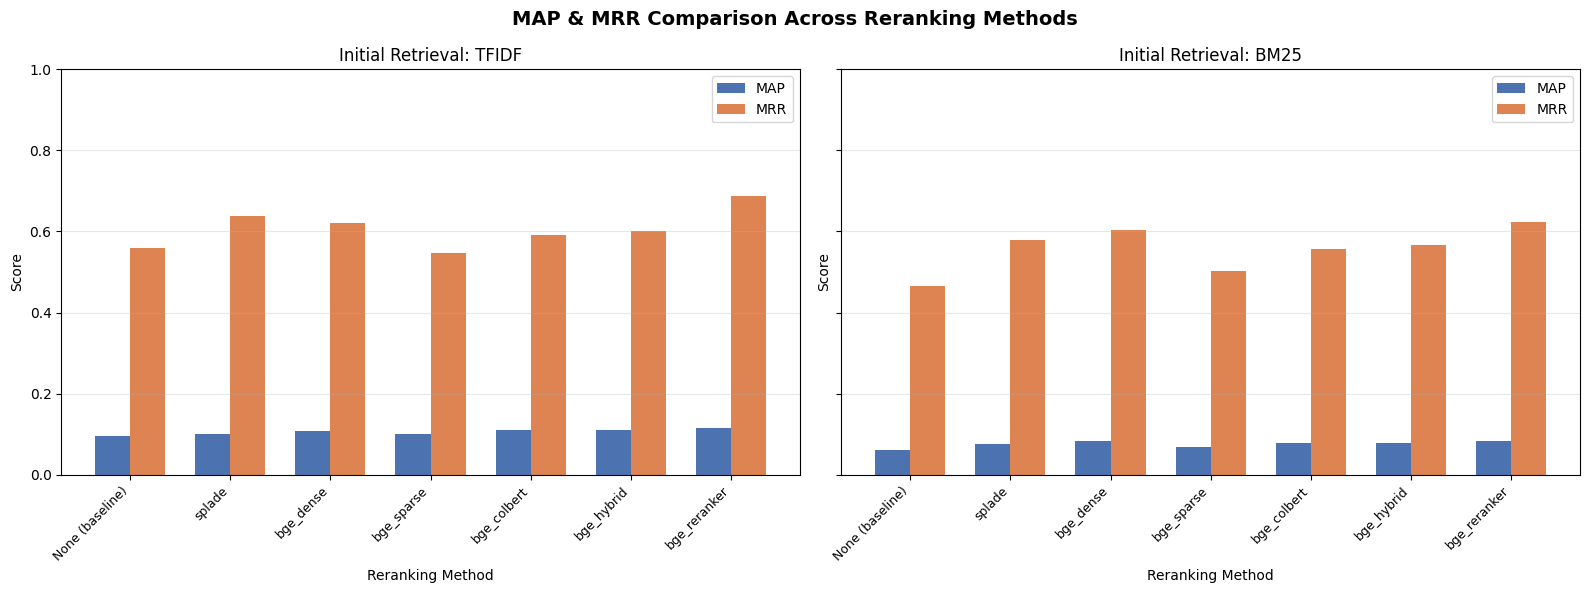

Saved: results_map_mrr.png


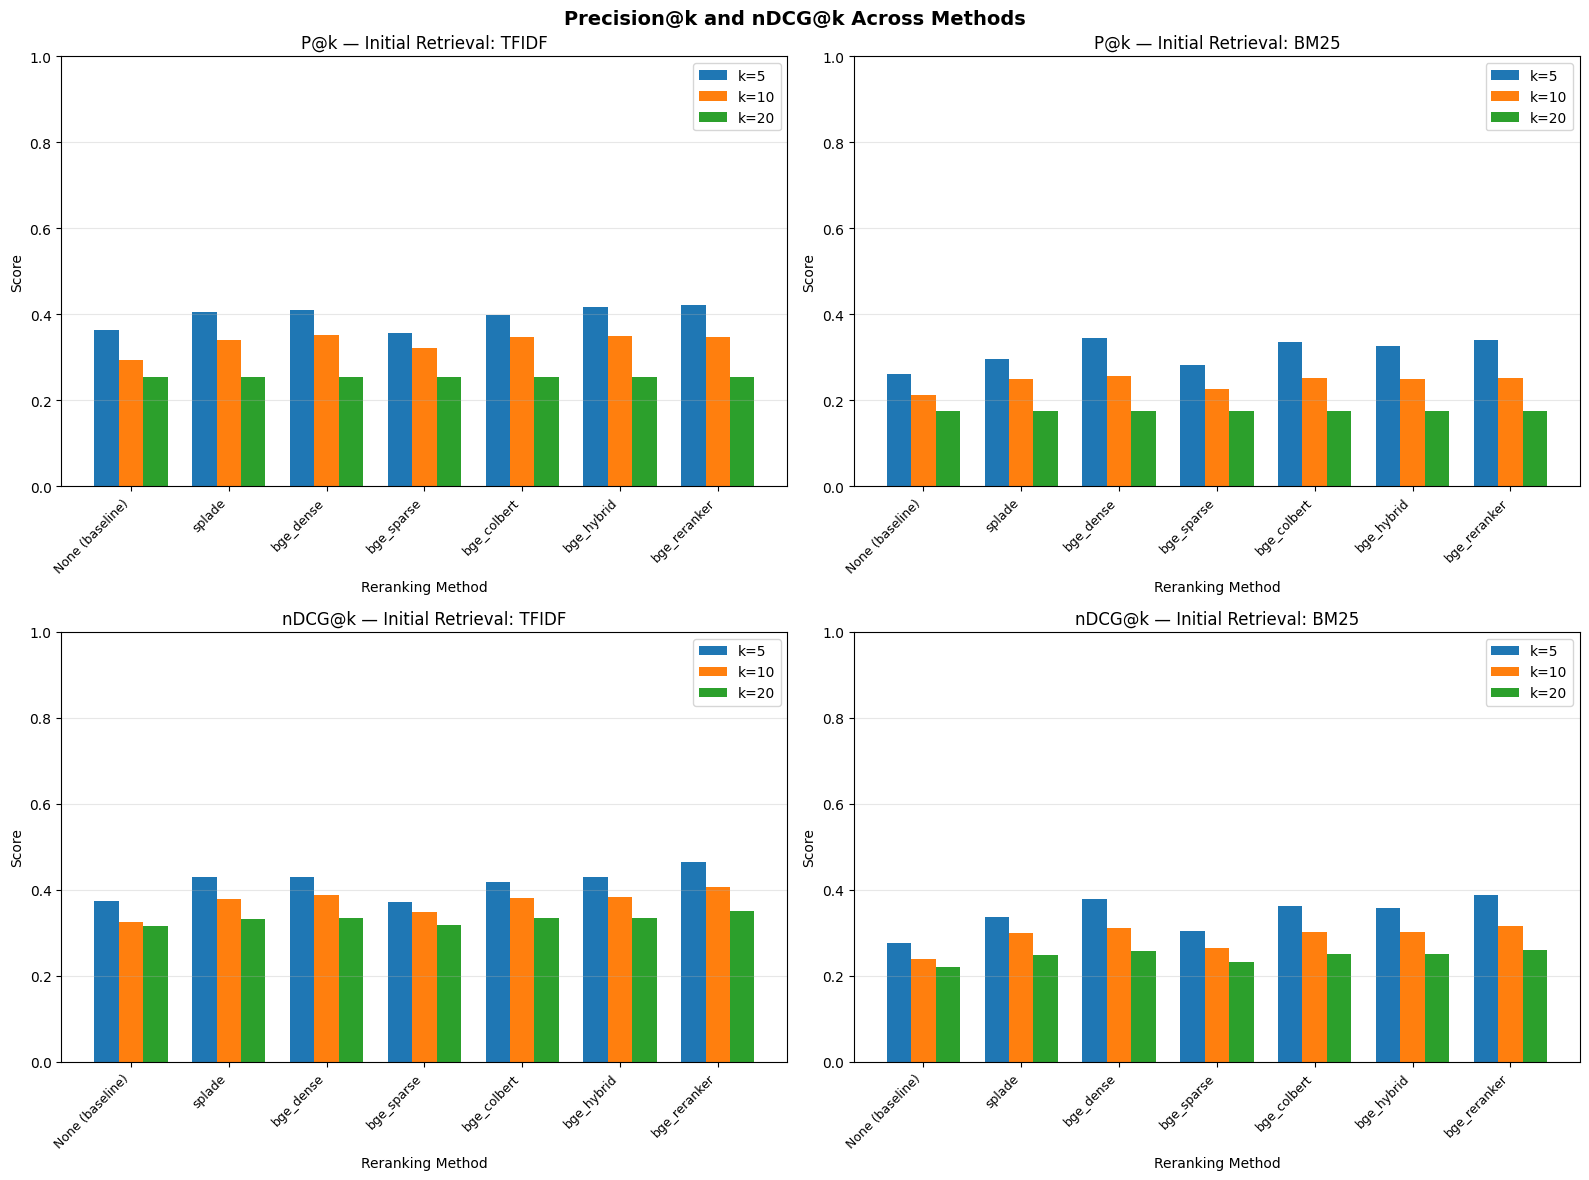

Saved: results_precision_ndcg.png


In [25]:
rows = []

# Baselines
for ret_name in RETRIEVAL_METHODS:
    metrics_list = baseline_results[ret_name]
    avg = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0]}
    row = {"Retrieval": ret_name.upper(), "Reranker": "None (baseline)"}
    row.update(avg)
    rows.append(row)

# Reranked
for (ret_name, method), metrics_list in all_results.items():
    avg = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0]}
    row = {"Retrieval": ret_name.upper(), "Reranker": method}
    row.update(avg)
    rows.append(row)

df = pd.DataFrame(rows)

# Reorder columns
metric_cols = [c for c in df.columns if c not in ("Retrieval", "Reranker")]
df = df[["Retrieval", "Reranker"] + sorted(metric_cols)]

print("\n" + "="*80)
print("FULL RESULTS TABLE")
print("="*80)
print(df.to_string(index=False, float_format="%.4f"))
print()

# %% — Bar chart: MAP comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax_idx, ret_name in enumerate(RETRIEVAL_METHODS):
    ax = axes[ax_idx]
    subset = df[df["Retrieval"] == ret_name.upper()]
    methods = subset["Reranker"].tolist()
    map_scores = subset["MAP"].tolist()
    mrr_scores = subset["MRR"].tolist()

    x = np.arange(len(methods))
    width = 0.35

    bars1 = ax.bar(x - width/2, map_scores, width, label="MAP", color="#4C72B0")
    bars2 = ax.bar(x + width/2, mrr_scores, width, label="MRR", color="#DD8452")

    ax.set_xlabel("Reranking Method")
    ax.set_ylabel("Score")
    ax.set_title(f"Initial Retrieval: {ret_name.upper()}")
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=9)
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("MAP & MRR Comparison Across Reranking Methods", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(".", "results_map_mrr.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_map_mrr.png")

# %% — Bar chart: Precision and nDCG at different k values
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row_idx, metric_prefix in enumerate(["P", "nDCG"]):
    for col_idx, ret_name in enumerate(RETRIEVAL_METHODS):
        ax = axes[row_idx][col_idx]
        subset = df[df["Retrieval"] == ret_name.upper()]
        methods = subset["Reranker"].tolist()

        x = np.arange(len(methods))
        width = 0.25

        for k_idx, k in enumerate(K_VALUES):
            col_name = f"{metric_prefix}@{k}"
            values = subset[col_name].tolist()
            ax.bar(x + (k_idx - 1) * width, values, width, label=f"k={k}")

        ax.set_xlabel("Reranking Method")
        ax.set_ylabel("Score")
        ax.set_title(f"{metric_prefix}@k — Initial Retrieval: {ret_name.upper()}")
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=9)
        ax.legend()
        ax.set_ylim(0, 1.0)
        ax.grid(axis="y", alpha=0.3)

plt.suptitle("Precision@k and nDCG@k Across Methods", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(".", "results_precision_ndcg.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_precision_ndcg.png")


  FULL RESULTS TABLE  (RED = best per retrieval method for that metric)

  --- Initial Retrieval: TFIDF ---
  Reranker                F1@10    F1@20     F1@5      MAP      MRR     P@10     P@20      P@5     R@10     R@20      R@5  nDCG@10  nDCG@20   nDCG@5
  --------------------------------------------------------------------------------------------------------------------------------------------------
  None (baseline)      0.1376   0.1752** 0.1103   0.0961   0.5588   0.2934   0.2533** 0.3632   0.1057   0.1932** 0.0724   0.3254   0.3149   0.3737  
  splade               0.1512   0.1752** 0.1078   0.1001   0.6380   0.3395   0.2533** 0.4053   0.1238   0.1932** 0.0776   0.3785   0.3308   0.4285  
  bge_dense            0.1666** 0.1752** 0.1164   0.1081   0.6200   0.3513** 0.2533** 0.4105   0.1403** 0.1932** 0.0847   0.3880   0.3346   0.4285  
  bge_sparse           0.1436   0.1752** 0.1001   0.0992   0.5458   0.3211   0.2533** 0.3553   0.1190   0.1932** 0.0737   0.3479   0.3171   0.3706

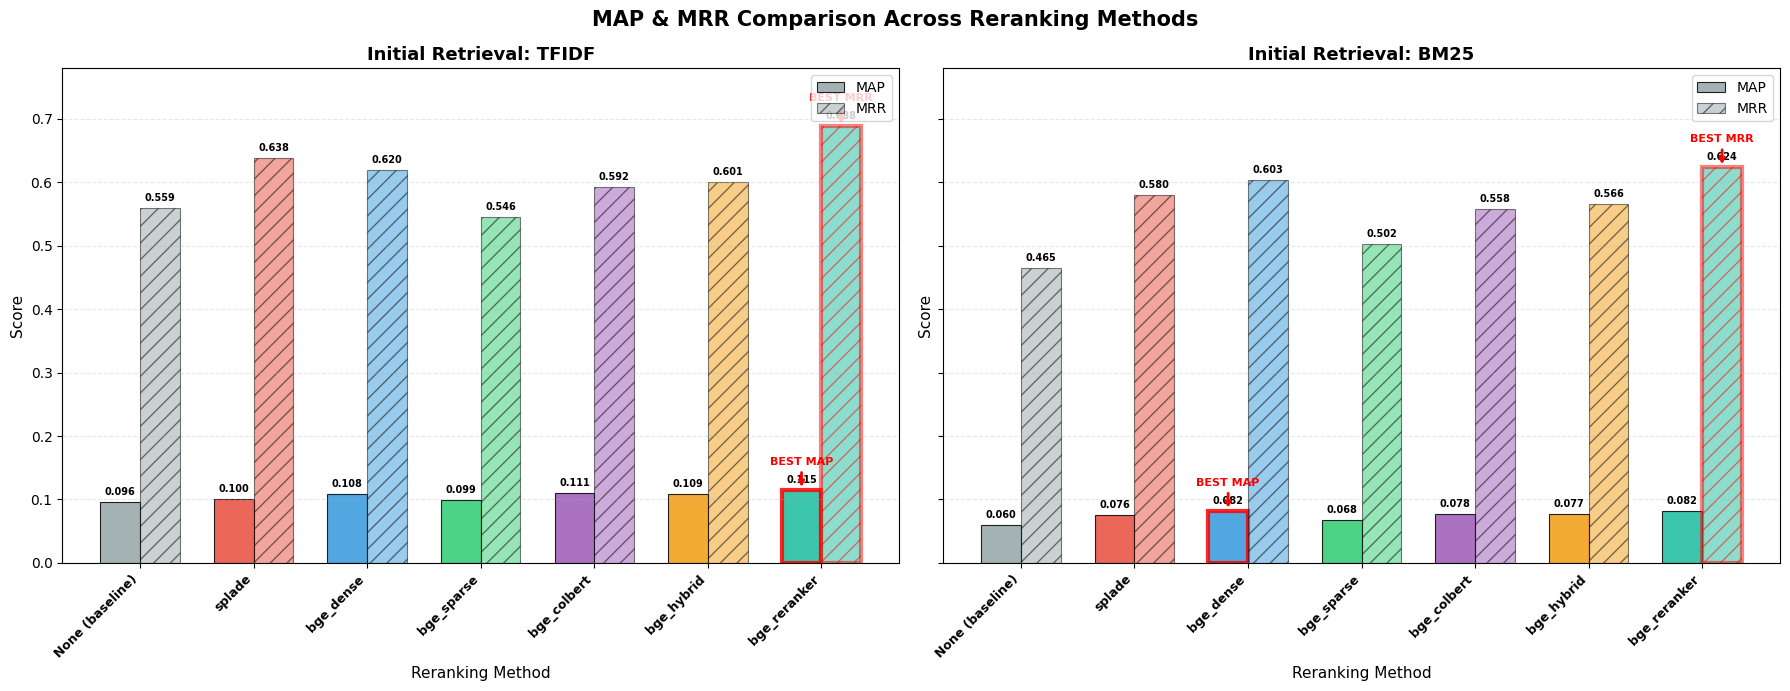

Saved: results_map_mrr.png


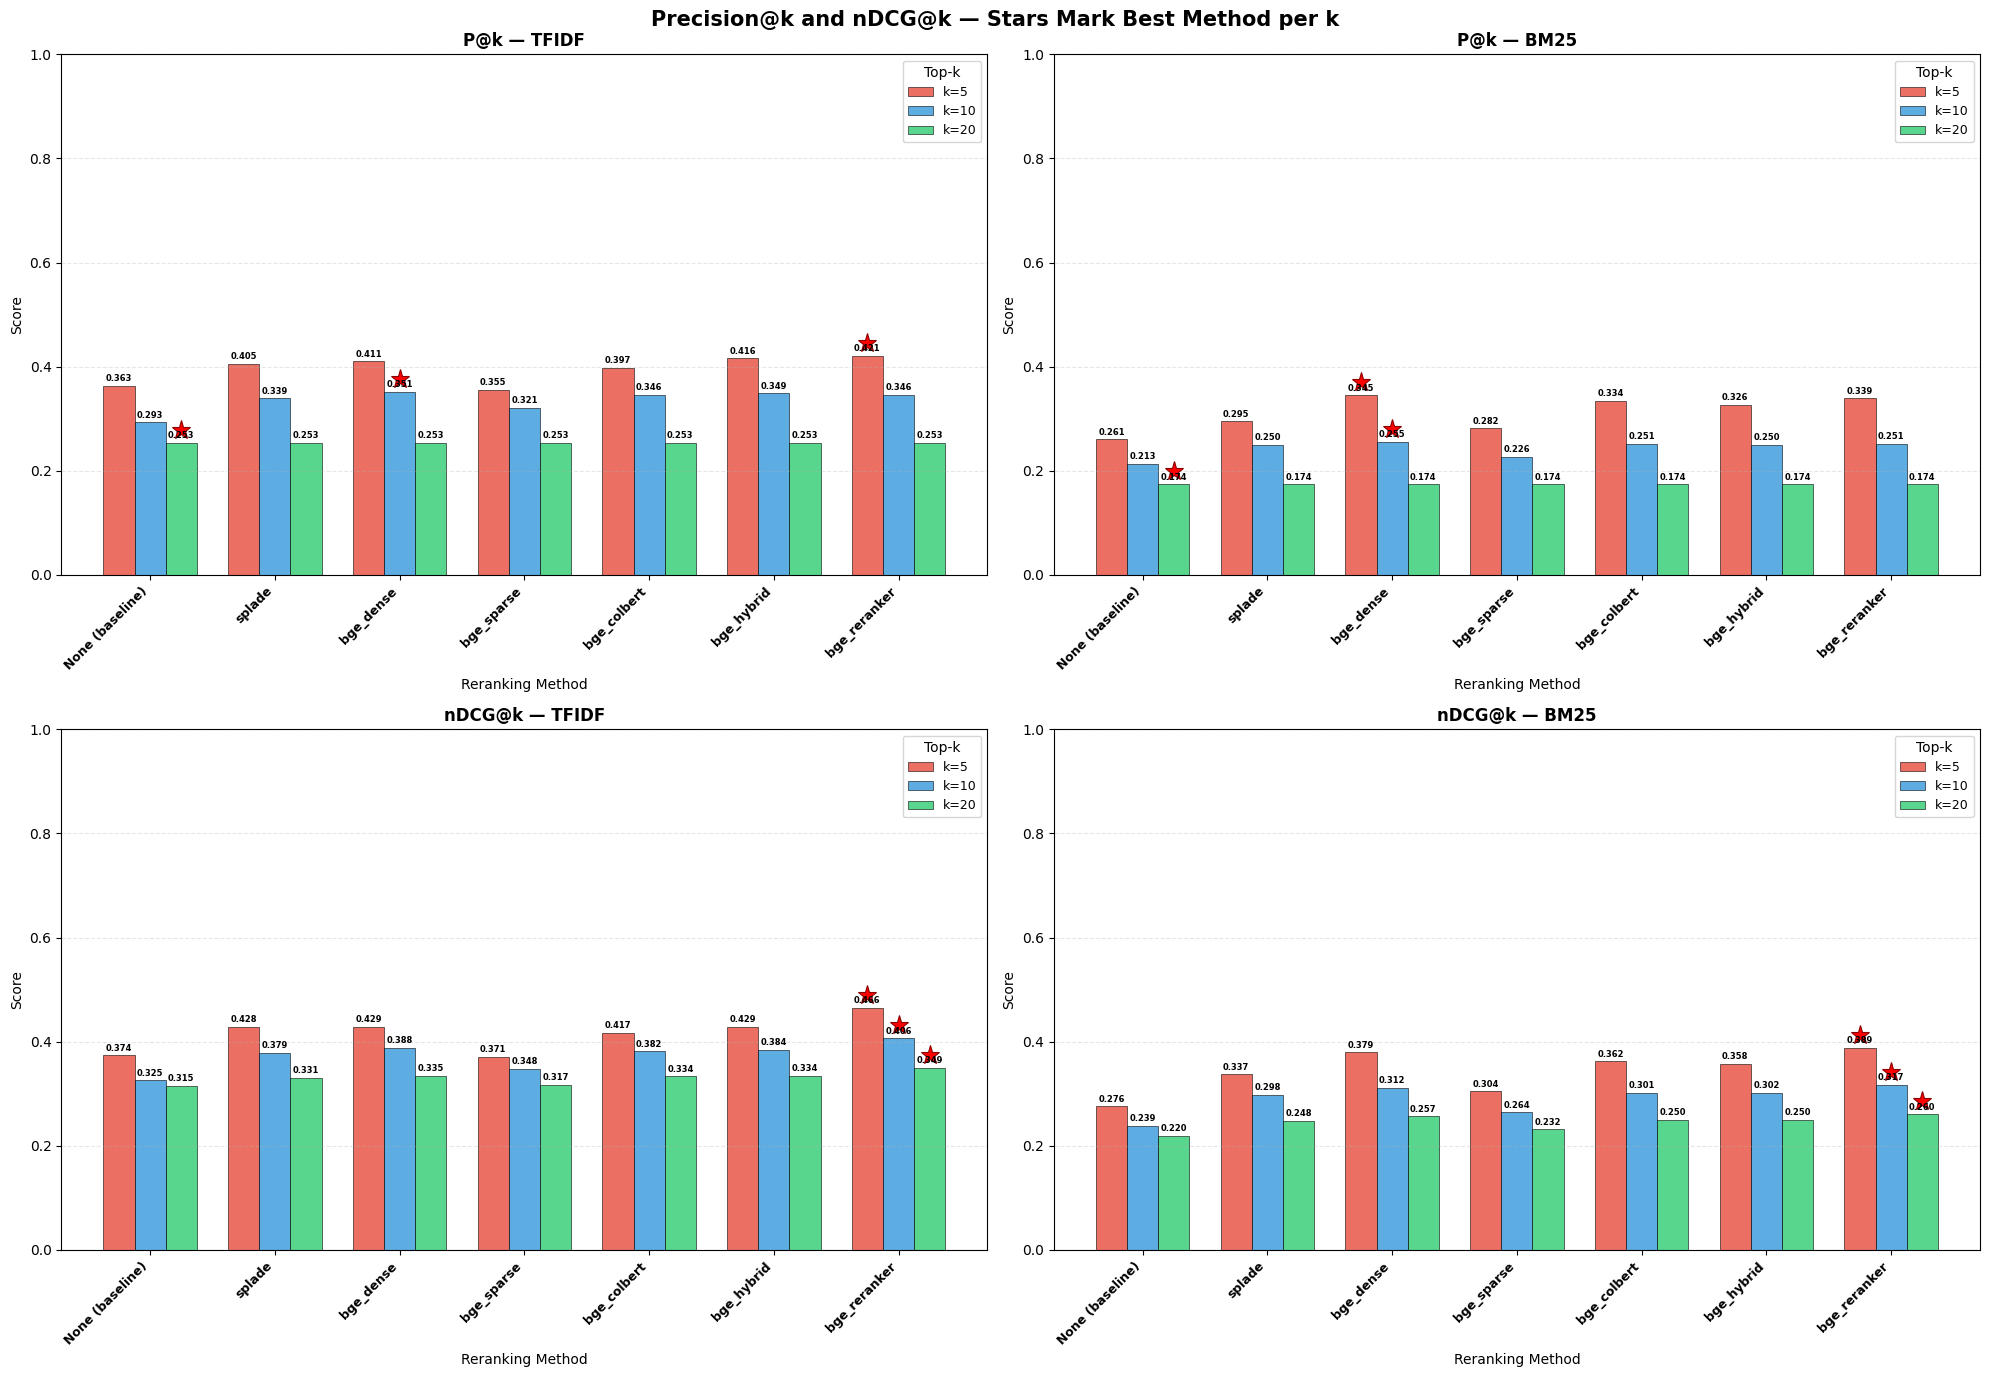

Saved: results_precision_ndcg.png

  WINNER SUMMARY — Best Reranker Per Metric

  Initial Retrieval: TFIDF
  Metric       Best Reranker             Score
  --------------------------------------------
  F1@10        bge_dense                0.1666
  F1@20        None (baseline)          0.1752
  F1@5         bge_reranker             0.1201
  MAP          bge_reranker             0.1150
  MRR          bge_reranker             0.6884
  P@10         bge_dense                0.3513
  P@20         None (baseline)          0.2533
  P@5          bge_reranker             0.4211
  R@10         bge_dense                0.1403
  R@20         None (baseline)          0.1932
  R@5          bge_reranker             0.0973
  nDCG@10      bge_reranker             0.4061
  nDCG@20      bge_reranker             0.3493
  nDCG@5       bge_reranker             0.4656

  >>> OVERALL WINNER: bge_reranker (8/14 metrics won)

  Initial Retrieval: BM25
  Metric       Best Reranker             Score
  ----------

In [34]:
rows = []

# Baselines
for ret_name in RETRIEVAL_METHODS:
    metrics_list = baseline_results[ret_name]
    avg = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0]}
    row = {"Retrieval": ret_name.upper(), "Reranker": "None (baseline)"}
    row.update(avg)
    rows.append(row)

# Reranked
for (ret_name, method), metrics_list in all_results.items():
    avg = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0]}
    row = {"Retrieval": ret_name.upper(), "Reranker": method}
    row.update(avg)
    rows.append(row)

df = pd.DataFrame(rows)

# Reorder columns
metric_cols = sorted([c for c in df.columns if c not in ("Retrieval", "Reranker")])
df = df[["Retrieval", "Reranker"] + metric_cols]

# ---- Consistent color palette for each reranker method ----
METHOD_COLORS = {
    "None (baseline)": "#95A5A6",  # grey
    "splade":          "#E74C3C",  # red
    "bge_dense":       "#3498DB",  # blue
    "bge_sparse":      "#2ECC71",  # green
    "bge_colbert":     "#9B59B6",  # purple
    "bge_hybrid":      "#F39C12",  # orange
    "bge_reranker":    "#1ABC9C",  # teal
}

SAVE_DIR = "."

# %% — 10a. Styled Results Table (print with best highlighted in RED)

# ANSI color codes for terminal output
RED = "\033[91m"
RED_BOLD = "\033[1;91m"
BOLD = "\033[1m"
RESET = "\033[0m"

print("\n" + "=" * 90)
print(f"  FULL RESULTS TABLE  ({RED_BOLD}RED = best{RESET} per retrieval method for that metric)")
print("=" * 90)

for ret_name in RETRIEVAL_METHODS:
    subset = df[df["Retrieval"] == ret_name.upper()].copy()
    print(f"\n  --- Initial Retrieval: {BOLD}{ret_name.upper()}{RESET} ---")
    header = f"  {'Reranker':<20}"
    for col in metric_cols:
        header += f" {col:>8}"
    print(header)
    print("  " + "-" * (20 + 9 * len(metric_cols)))

    # Find best value per metric column
    best_vals = {col: subset[col].max() for col in metric_cols}

    for _, row in subset.iterrows():
        line = f"  {row['Reranker']:<20}"
        for col in metric_cols:
            val = row[col]
            if abs(val - best_vals[col]) < 1e-8:
                line += f" {RED_BOLD}{val:>6.4f}**{RESET}"
            else:
                line += f" {val:>6.4f}  "
        print(line)

print()

# %% — 10b. MAP & MRR Bar Chart with value labels and best-model highlight
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax_idx, ret_name in enumerate(RETRIEVAL_METHODS):
    ax = axes[ax_idx]
    subset = df[df["Retrieval"] == ret_name.upper()]
    methods = subset["Reranker"].tolist()
    map_scores = subset["MAP"].tolist()
    mrr_scores = subset["MRR"].tolist()
    colors = [METHOD_COLORS.get(m, "#333333") for m in methods]

    x = np.arange(len(methods))
    width = 0.35

    # MAP bars
    best_map_i = int(np.argmax(map_scores))
    best_mrr_i = int(np.argmax(mrr_scores))
    map_edges = ["red" if i == best_map_i else "black" for i in range(len(methods))]
    map_lws = [3.0 if i == best_map_i else 0.8 for i in range(len(methods))]
    mrr_edges = ["red" if i == best_mrr_i else "black" for i in range(len(methods))]
    mrr_lws = [3.0 if i == best_mrr_i else 0.8 for i in range(len(methods))]

    bars_map = ax.bar(x - width / 2, map_scores, width, label="MAP",
                      color=colors, edgecolor=map_edges, linewidth=map_lws, alpha=0.85)
    # MRR bars (same colors, hatched to distinguish)
    bars_mrr = ax.bar(x + width / 2, mrr_scores, width, label="MRR",
                      color=colors, edgecolor=mrr_edges, linewidth=mrr_lws, alpha=0.50, hatch="//")

    # Value labels on top of each bar
    for bar in bars_map:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008, f"{h:.3f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")
    for bar in bars_mrr:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008, f"{h:.3f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

    # Highlight best MAP with arrow
    ax.annotate("BEST MAP", xy=(x[best_map_i] - width / 2, map_scores[best_map_i]),
                xytext=(0, 18), textcoords="offset points", ha="center",
                fontsize=8, fontweight="bold", color="red",
                arrowprops=dict(arrowstyle="->", color="red", lw=2.0))

    # Highlight best MRR with arrow
    ax.annotate("BEST MRR", xy=(x[best_mrr_i] + width / 2, mrr_scores[best_mrr_i]),
                xytext=(0, 18), textcoords="offset points", ha="center",
                fontsize=8, fontweight="bold", color="red",
                arrowprops=dict(arrowstyle="->", color="red", lw=2.0))

    ax.set_xlabel("Reranking Method", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(f"Initial Retrieval: {ret_name.upper()}", fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=9, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10)
    ax.set_ylim(0, max(max(map_scores), max(mrr_scores)) * 1.25)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.suptitle("MAP & MRR Comparison Across Reranking Methods", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "results_map_mrr.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_map_mrr.png")

# %% — 10c. Grouped Bar Chart: Precision@k and nDCG@k with highlights
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
k_colors = {5: "#E74C3C", 10: "#3498DB", 20: "#2ECC71"}

for row_idx, metric_prefix in enumerate(["P", "nDCG"]):
    for col_idx, ret_name in enumerate(RETRIEVAL_METHODS):
        ax = axes[row_idx][col_idx]
        subset = df[df["Retrieval"] == ret_name.upper()]
        methods = subset["Reranker"].tolist()

        x = np.arange(len(methods))
        width = 0.25

        for k_idx, k in enumerate(K_VALUES):
            col_name = f"{metric_prefix}@{k}"
            values = subset[col_name].tolist()
            bars = ax.bar(x + (k_idx - 1) * width, values, width,
                          label=f"k={k}", color=k_colors[k], alpha=0.80,
                          edgecolor="black", linewidth=0.5)

            # Value labels
            for bar in bars:
                h = bar.get_height()
                if h > 0.001:
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}",
                            ha="center", va="bottom", fontsize=6, fontweight="bold")

            # Red star on best method for this k
            best_idx = int(np.argmax(values))
            ax.plot(x[best_idx] + (k_idx - 1) * width, values[best_idx] + 0.025,
                    marker="*", color="red", markersize=14, markeredgecolor="darkred",
                    markeredgewidth=0.8)

        ax.set_xlabel("Reranking Method", fontsize=10)
        ax.set_ylabel("Score", fontsize=10)
        ax.set_title(f"{metric_prefix}@k — {ret_name.upper()}", fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=9, fontweight="bold")
        ax.legend(loc="upper right", fontsize=9, title="Top-k")
        ax.set_ylim(0, 1.0)
        ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.suptitle("Precision@k and nDCG@k — Stars Mark Best Method per k", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "results_precision_ndcg.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_precision_ndcg.png")





# %% — 10f. Winner Summary (with RED highlighting)
print("\n" + "=" * 90)
print(f"  {RED_BOLD}WINNER SUMMARY{RESET} — Best Reranker Per Metric")
print("=" * 90)

for ret_name in RETRIEVAL_METHODS:
    subset = df[df["Retrieval"] == ret_name.upper()]
    print(f"\n  {'='*40}")
    print(f"  Initial Retrieval: {BOLD}{ret_name.upper()}{RESET}")
    print(f"  {'='*40}")
    print(f"  {'Metric':<12} {'Best Reranker':<22} {'Score':>8}")
    print(f"  {'-'*44}")
    for col in metric_cols:
        best_row = subset.loc[subset[col].idxmax()]
        print(f"  {col:<12} {RED_BOLD}{best_row['Reranker']:<22}{RESET} {RED_BOLD}{best_row[col]:>8.4f}{RESET}")

    # Overall winner (most metrics won)
    wins = {}
    for col in metric_cols:
        winner = subset.loc[subset[col].idxmax(), "Reranker"]
        wins[winner] = wins.get(winner, 0) + 1
    overall_winner = max(wins, key=wins.get)
    print(f"\n  >>> {RED_BOLD}OVERALL WINNER: {overall_winner} ({wins[overall_winner]}/{len(metric_cols)} metrics won){RESET}")

print("\n" + "=" * 90)
